# EDA General de 'ventas_productos'

In [55]:
##### Importacion de modulos
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import os

##### Cambiando directorio
print(os.getcwd())
if os.getcwd().split('\\')[-1] != 'PostSQL':
    os.chdir('./Datos/PostSQL')


c:\Users\JP\Documents\DSProyectos\4_DemandaForecasting\Datos\PostSQL


In [56]:
##### Leyendo y Cargando datos
df = pd.read_csv('ventas_productos.csv')


##### Fechas y Datetime
#### Transformanco fechas a DateTime
# df['fecha'] = pd.to_datetime(
#     df['fecha'],
#     format='%d/%m/%Y',
#     dayfirst=True,
#     errors='coerce'
# )
#### Verificando que todos los datos son del anio 2024
ds_anio = df['fecha'].apply(lambda fila: fila.split('/')[-1])\
    .value_counts()
#### Creando columnas: dia, mes
df['dia'] = df['fecha'].apply(lambda fila: int(fila.split('/')[0]))
df['mes'] = df['fecha'].apply(lambda fila: int(fila.split('/')[1]))
#### Ordenando datos por fecha
df = df.drop(columns='fecha')\
    .sort_values(by=['mes','dia'], ascending=[True, True])\
    .reset_index(drop=True)
#### Resumen
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_venta    3000 non-null   int64
 1   cliente_id  3000 non-null   int64
 2   cantidad    3000 non-null   int64
 3   stock       3000 non-null   int64
 4   nombre      3000 non-null   str  
 5   categoria   3000 non-null   str  
 6   precio      3000 non-null   int64
 7   dia         3000 non-null   int64
 8   mes         3000 non-null   int64
dtypes: int64(7), str(2)
memory usage: 211.1 KB


In [57]:
##### Separacion de variables numericas y categoricas
cuant_vars = list(df._get_numeric_data().columns.values)
cual_vars = list(set(df.columns) - set(cuant_vars))
display(df[cuant_vars].describe())
display(df[cual_vars].describe())


,id_venta,cliente_id,cantidad,stock,precio,dia,mes
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,1500.500000,162.302333,3.480333,3118.315000,7873.433333,15.780333,6.98000
std,866.169729,94.368925,1.705261,1152.234129,4395.233430,8.847721,3.11804
min,1.000000,1.000000,1.000000,1363.000000,2600.000000,1.000000,1.00000
25%,750.750000,79.000000,2.000000,2182.000000,4400.000000,8.000000,4.00000
50%,1500.500000,162.000000,3.000000,3140.000000,6600.000000,16.000000,7.00000
75%,2250.250000,244.000000,5.000000,4043.000000,10800.000000,23.000000,10.00000
max,3000.000000,326.000000,6.000000,5137.000000,22800.000000,31.000000,12.00000


,nombre,categoria
count,3000,3000
unique,38,8
top,Hamburgesas congeladas,Carniceria
freq,105,453


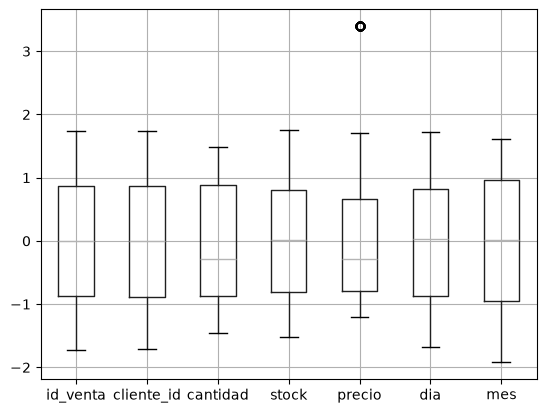

graph for nombre: total = 30


C:\Users\JP\AppData\Local\Temp\ipykernel_5700\512232820.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


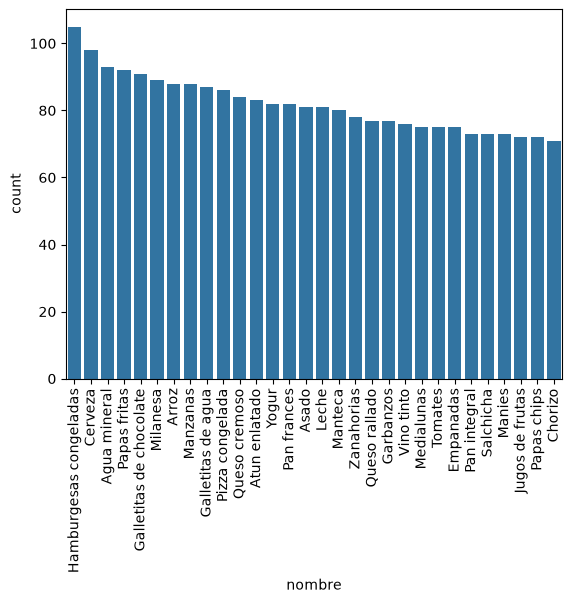

graph for categoria: total = 8


C:\Users\JP\AppData\Local\Temp\ipykernel_5700\512232820.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


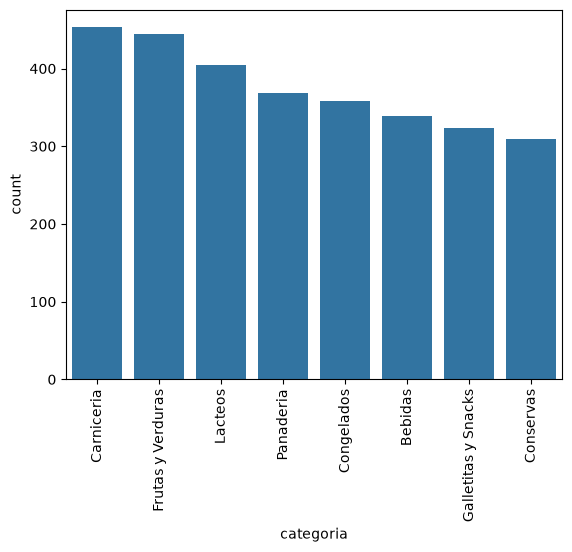

In [59]:
##### Visualizacion
#### Cuant Boxplots
    # Analisis: Solo 'precio' tienen un valor atipico, que es el asado
df_norm = (df[cuant_vars] - df[cuant_vars].mean())/df[cuant_vars].std(ddof=0)
df_norm.boxplot(column=cuant_vars)
plt.show()
del df_norm
#### Cual Histogramas
for col in cual_vars:
    cat_num = df[col].value_counts()[:30]
    print("graph for %s: total = %d" % (col, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

,id_venta,cliente_id,cantidad,stock,nombre,categoria,precio,dia,mes
id_venta,1.000,0.015,-0.031,0.025,0.007,0.020,-0.020,-0.001,-0.022
cliente_id,0.015,1.000,-0.021,0.012,0.006,0.013,0.012,0.022,0.004
cantidad,-0.031,-0.021,1.000,0.027,-0.049,-0.036,0.012,-0.001,0.008
stock,0.025,0.012,0.027,1.000,-0.190,0.045,-0.005,0.002,0.016
nombre,0.007,0.006,-0.049,-0.190,1.000,0.305,0.096,-0.018,-0.014
categoria,0.020,0.013,-0.036,0.045,0.305,1.000,-0.225,-0.009,-0.018
precio,-0.020,0.012,0.012,-0.005,0.096,-0.225,1.000,0.014,0.004
dia,-0.001,0.022,-0.001,0.002,-0.018,-0.009,0.014,1.000,-0.013
mes,-0.022,0.004,0.008,0.016,-0.014,-0.018,0.004,-0.013,1.000


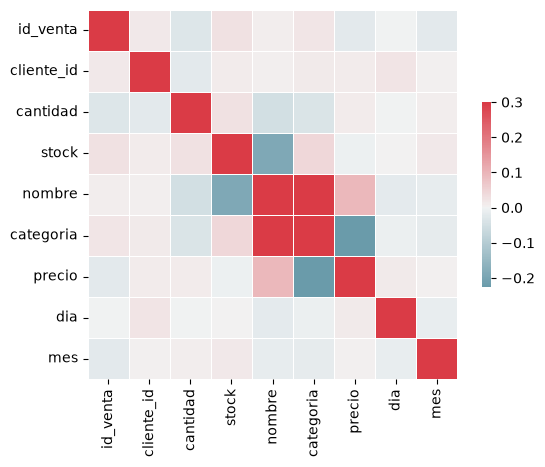

<StringArray>
[            'Bebidas',          'Carniceria',          'Congelados',
           'Conservas',   'Frutas y Verduras', 'Galletitas y Snacks',
             'Lacteos',           'Panaderia']
Length: 8, dtype: str

In [ ]:
##### Correlacion
#### Transformando cual varaibles en label encoders
df_corr = df.copy()
le = LabelEncoder()
for col in cual_vars:
    df_corr[col] = le.fit_transform(df[col])
        # El mapping se hace alfabeticamente
        # (Alfabeto -> numero)
#### Visual
display(df_corr.corr().round(3))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df_corr.corr(),vmax=.3, center=0, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()
##### Analisis
#### Resumen
    # Ninguno de los |valores| < 0.305
    # Ende: no ha correlacon alta entre las variables
#### Neg Corr: Stock y Nombre
display(df['nombre'].sort_values().unique())
    # Parece que los labels numerals, de nombre, con valores
            # altos tienden a ser frutas y verduras, a las
            # cuales generalmente no se hace mucho stock
        # Ende: alto label => bajo stock
#### Neg corr: categoria y precio
display(df['categoria'].sort_values().unique())
    # Cagegoria: Los labels con valores bajos son 'carniceria'
            # y 'bebidas', que generalmente son mas caras
        # Mientras que los valores altos son 'panaderia' y 
                # 'lacteos', que generalmente son mas baratos
        # Ende: alto label de categoria significa mas bajo precios